# How noise channels are attached to a Stim circuit

Every operation `YbCircuit` supports lowers to the ideal Stim instruction plus
the noise channels that operation exposes the atom to. This notebook walks
through those operations one at a time and prints exactly what comes out, so
that the composition rules in [`docs/channel_ordering.md`](../docs/channel_ordering.md)
can be read off a real circuit rather than taken on trust.

The three encodings behave differently at every step, so each operation is
shown for all of them:

| Encoding | `isotope`, `qubit_type` | Computational states |
|---|---|---|
| <sup>174</sup>Yb optical clock qubit | `"174"`, `"gm"` | \|0⟩ = \|g⟩ (<sup>1</sup>S<sub>0</sub>), \|1⟩ = \|m⟩ (<sup>3</sup>P<sub>0</sub>) |
| <sup>171</sup>Yb ground nuclear spin | `"171"`, `"g"` | two <sup>1</sup>S<sub>0</sub> spin states |
| <sup>171</sup>Yb metastable nuclear spin | `"171"`, `"m"` | two <sup>3</sup>P<sub>0</sub> spin states |

Channel names below are the paper's; [`docs/channel_reference.md`](../docs/channel_reference.md)
maps them to the Python identifiers.

**How to read the listings.** Channels act right to left in the paper's
notation, which in a Stim circuit is the same as top to bottom: an instruction
acts after everything printed above it. Noise attached to a measurement
therefore appears *before* the `M`, because it happens to the atom before the
photons are counted. Loss and decay out of the computational subspace are
`HERALDED_ERASE`; twirled Pauli channels are `PAULI_CHANNEL_1`, `DEPOLARIZE1`,
`DEPOLARIZE2`, `X_ERROR` or `Z_ERROR`.

One Stim detail to keep in mind while counting lines: identical consecutive
instructions with identical arguments are fused, so two channels that happen to
share a probability can arrive as a single instruction with a qubit listed twice.

## Setup

In [1]:
from collections import Counter

import stim
from IPython.display import display

from dualybsim import NoiseModelParameters, QubitManager, YbCircuit, YbNoiseModel

PARAMS = NoiseModelParameters()


def qubits(*specs):
    """QubitManager from (id, isotope, qubit_type, role) tuples."""
    manager = QubitManager()
    for qubit_id, isotope, qubit_type, role in specs:
        manager.add_qubit(qubit_id, isotope=isotope, qubit_type=qubit_type, role=role)
    return manager


def show(circuit, *, diagram=True):
    """Print the emitted instructions, numbered, then draw the timeline."""
    for line, instruction in enumerate(circuit, start=1):
        print(f"{line:>3}  {instruction}")
    if diagram:
        display(circuit.diagram("timeline-svg"))


def channel_counts(circuit):
    """How many instructions of each kind the circuit ended up with."""
    return dict(sorted(Counter(i.name for i in circuit.flattened()).items()))

`YbCircuit` inserts noise as you build, so a one-operation circuit is the
smallest thing that shows a channel stack. Noise is on by default; pass
`noise_enabled=False` for the ideal version of the same circuit.

In [2]:
clock = qubits((0, "174", "gm", "data"))

YbCircuit(clock, PARAMS).single_qubit_gate("H", 0)

stim.Circuit('''
    H 0
    DEPOLARIZE1(0.0001) 0
    PAULI_CHANNEL_1(1.25e-06, 1.25e-06, 0) 0
    HERALDED_ERASE(3.33333e-06) 0
''')

In [3]:
YbCircuit(clock, PARAMS, noise_enabled=False).single_qubit_gate("H", 0)

stim.Circuit('''
    H 0
''')

## <sup>174</sup>Yb clock qubit

The clock qubit spans both manifolds, so `m → g` decay stays inside the
computational subspace and acts as amplitude damping as idling error.

### Idling

```
I~(c) = D . [ZERR_c (+) DECAY_mg] . I
```

| Line | Channel |
|---|---|
| 1 | the ideal identity |
| 2 | `ZERR_c` and `DECAY_mg` twirled together — both act on the same two levels, so they are one channel: `p_X = p_Y = p_1/4`, `p_Z = p_2/2 − p_1/4` |
| 3 | `LOSS_g` / `LOSS_m`, trap loss over the same window |

  1  I 0
  2  PAULI_CHANNEL_1(1.24997e-05, 1.24997e-05, 8.74903e-05) 0
  3  HERALDED_ERASE(3.33328e-05) 0


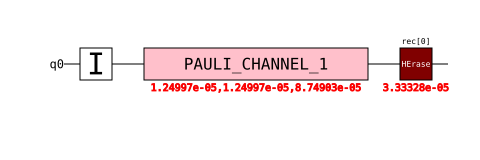

In [4]:
show(YbCircuit(clock, PARAMS).idling(0, duration=1e-3))

Here, `p_1` and `p_2` are follows `p(t) = 1 − exp(−t/T)`. So the probabilities are different of duration time of the idling.

In [5]:
for duration in (1e-6, 1e-4, 1e-2):
    circuit = YbCircuit(clock, PARAMS).idling(0, duration=duration)
    print(f"duration = {duration:.0e} s")
    show(circuit, diagram=False)
    print()

duration = 1e-06 s
  1  I 0
  2  PAULI_CHANNEL_1(1.25e-08, 1.25e-08, 8.75e-08) 0
  3  HERALDED_ERASE(3.33333e-08) 0

duration = 1e-04 s
  1  I 0
  2  PAULI_CHANNEL_1(1.25e-06, 1.25e-06, 8.7499e-06) 0
  3  HERALDED_ERASE(3.33333e-06) 0

duration = 1e-02 s
  1  I 0
  2  PAULI_CHANNEL_1(0.000124969, 0.000124969, 0.000874032) 0
  3  HERALDED_ERASE(0.000333278) 0



### Single-qubit gate

```
U~(1Q, c) = D . DEP1_c . U(1Q)
```

| Line | Channel |
|---|---|
| 1 | the ideal gate |
| 2 | `DEP1_c`, the depolarising error of the clock pulse |
| 3 | `DECAY_mg` over `t_1Q`. `p_Z = 0`: inside a coherent-control operation the idling `ZERR` is disabled, since its contribution is already in `DEP1_c` |
| 4 | trap loss over `t_1Q` |

  1  H 0
  2  DEPOLARIZE1(0.0001) 0
  3  PAULI_CHANNEL_1(1.25e-06, 1.25e-06, 0) 0
  4  HERALDED_ERASE(3.33333e-06) 0


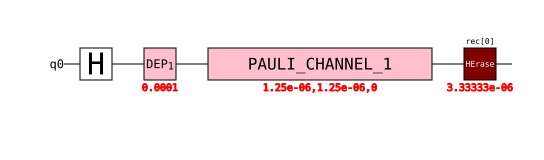

In [6]:
show(YbCircuit(clock, PARAMS).single_qubit_gate("H", 0))

Any single-qubit Clifford gets the same stack — the channel does not know which
rotation it followed.

In [7]:
for gate in ("X", "H", "S", "SQRT_Y_DAG"):
    print(f"{gate}:", channel_counts(YbCircuit(clock, PARAMS).single_qubit_gate(gate, 0)))

X: {'DEPOLARIZE1': 1, 'HERALDED_ERASE': 1, 'PAULI_CHANNEL_1': 1, 'X': 1}
H: {'DEPOLARIZE1': 1, 'H': 1, 'HERALDED_ERASE': 1, 'PAULI_CHANNEL_1': 1}
S: {'DEPOLARIZE1': 1, 'HERALDED_ERASE': 1, 'PAULI_CHANNEL_1': 1, 'S': 1}
SQRT_Y_DAG: {'DEPOLARIZE1': 1, 'HERALDED_ERASE': 1, 'PAULI_CHANNEL_1': 1, 'SQRT_Y_DAG': 1}


### Two-qubit gate

```
U~(2Q) = D . DEP2_c . U(2Q)
```

The two qubit gates are mediated Rydberg blockade. The decays are separated to the three Rydberg branches.
They occur only while the atom is actually driven to \|r⟩, which is why they show up here and not in the idling stack.

| Line | Channel |
|---|---|
| 1 | the ideal `CZ` |
| 2 | `DEP2_c`, the two-qubit depolarising error |
| 3 | `LOSS_r`, decay from \|r⟩ straight out of the trap |
| 4 | `DECAY_rg` — for the clock qubit r → g lands on \|0⟩, i.e. a bit flip |
| 5 | `DECAY_rm` — r → m returns the population to \|1⟩ but destroys its phase |
| 6 | trap loss over `t_2Q` |

The branch probabilities carry a renormalisation, because splitting one aggregate Rydberg channel into three sequential ones means each later branch acts on a population the earlier ones have already depleted.

  1  CZ 0 1
  2  DEPOLARIZE2(0.001) 0 1
  3  HERALDED_ERASE(0.00305084) 0 1
  4  X_ERROR(0.00252014) 0 1
  5  Z_ERROR(0.000421082) 0 1
  6  HERALDED_ERASE(1e-08) 0 1


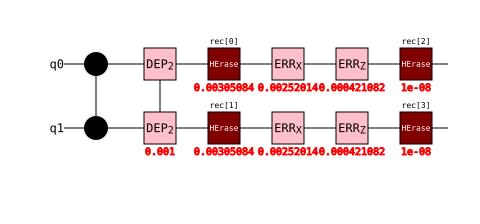

In [8]:
clock_pair = qubits((0, "174", "gm", "ancilla"), (1, "174", "gm", "data"))

show(YbCircuit(clock_pair, PARAMS).two_qubit_gate("CZ", [0, 1]))

In [9]:
PARAMS.rydberg_branch_rates(PARAMS.gate_time_c["t_2Q"])

{'LOSS_r': 0.003050838332493009,
 'DECAY_rg': 0.002520143648192478,
 'DECAY_rm': 0.00042108189070812327}

### Reset

```
R~(174) = D . LOSS_g^(reset) . R(174)
```

| Line | Channel |
|---|---|
| 1 | the ideal reset |
| 2 | `LOSS_g^(reset)`, loss during preparation and motional reset |
| 3 | `DECAY_mg` over `t_reset`, again in the damping limit |
| 4 | trap loss over `t_reset` |

  1  R 0
  2  HERALDED_ERASE(0.001) 0
  3  PAULI_CHANNEL_1(2.49988e-05, 2.49988e-05, 0) 0
  4  HERALDED_ERASE(6.66644e-05) 0


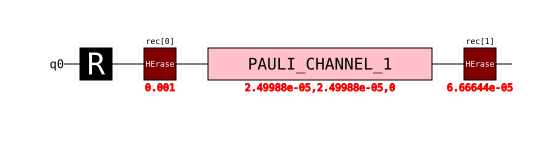

In [10]:
show(YbCircuit(clock, PARAMS).reset_qubit(0))

### Measurement

```
M~(174) = MERR . (D . LOSS_g^(meas)) . (D . DEP1_c . D_c) . (D . LOSS_g^(meas))
```

Readout is a sequence of state-selective imaging steps with an ideal clock
de-excitation (`D_c`) between them; the classical discrimination error `MERR`
lands once at the end of the quantum sequence. Everything is emitted before the
`M` on line 7.

| Line | Channel |
|---|---|
| 1 | `LOSS_g^(meas)`, atom loss during fluorescence imaging |
| 2 | `DECAY_mg` over `t_read` |
| 3 | `DEP1_c` from the clock pulse that swaps the manifolds between images |
| 4–5 | `MERR` after twirling: a loss part and a Pauli part |
| 6 | trap loss over `t_read` |
| 7 | the ideal measurement |

  1  HERALDED_ERASE(0.001) 0
  2  PAULI_CHANNEL_1(1.24997e-05, 1.24997e-05, 0) 0
  3  DEPOLARIZE1(0.0001) 0
  4  HERALDED_ERASE(9.999e-05) 0
  5  PAULI_CHANNEL_1(2.5005e-05, 2.5005e-05, 0) 0
  6  HERALDED_ERASE(3.33328e-05) 0
  7  M 0


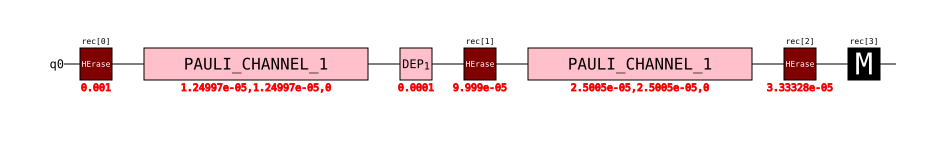

In [11]:
show(YbCircuit(clock, PARAMS).measurement(0))

In [12]:
PARAMS.get_twirled_174_measurement_merr_rates()

{'p_loss': 9.999000000000001e-05,
 'p_X': 2.5005000000000002e-05,
 'p_Y': 2.5005000000000002e-05,
 'p_Z': 0.0}

## <sup>171</sup>Yb metastable qubit

Both computational states sit in <sup>3</sup>P<sub>0</sub>, so `m → g` decay now
*leaves* the subspace: the same physical process that was amplitude damping for
the clock qubit is a loss channel here. Dephasing and spin relaxation appear as
separate `ZERR_m` and `XERR_m` rather than as one twirled Pauli channel.

### Idling

| Line | Channel |
|---|---|
| 1 | the ideal identity |
| 2 | `ZERR_m`, dephasing at `T_2^(m)` |
| 3 | `XERR_m`, spin relaxation at `T_1^(m)` |
| 4 | `DECAY_mg` as leakage out of the metastable manifold |
| 5 | trap loss |

  1  I 0
  2  Z_ERROR(9.9995e-05) 0
  3  X_ERROR(4.99999e-06) 0
  4  HERALDED_ERASE(0.0009995) 0
  5  HERALDED_ERASE(3.33328e-05) 0


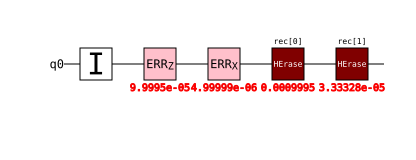

In [13]:
meta = qubits((0, "171", "m", "data"))

show(YbCircuit(meta, PARAMS).idling(0, duration=1e-3))

### Single-qubit gate

```
U~(1Q, m) = D . DECAY_mg^(gate) . DEP1_m . U(1Q)
```

| Line | Channel |
|---|---|
| 1 | the ideal gate |
| 2 | `DEP1_m` |
| 3 | `ZERR_m` over `t_1Q` |
| 4 | `DECAY_mg^(gate)` |
| 5 | trap loss over `t_1Q` |

`DECAY_mg^(gate)` is not the idling decay: it is metastable→ground damping
*driven by the nuclear-spin control laser*, so it is a fixed probability per gate
rather than a function of the gate time — which is why line 4 is four orders of
magnitude larger than the trap loss on line 5 over the same 1 µs.

  1  H 0
  2  DEPOLARIZE1(0.0001) 0
  3  Z_ERROR(1e-07) 0
  4  HERALDED_ERASE(0.001) 0
  5  HERALDED_ERASE(3.33333e-08) 0


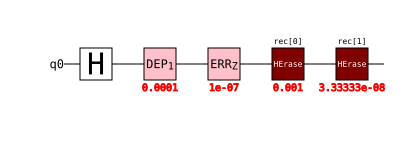

In [14]:
show(YbCircuit(meta, PARAMS).single_qubit_gate("H", 0))

### Two-qubit gate

The Rydberg branches regroup: `r → g` now leaves the computational subspace, so
`LOSS_r` and `DECAY_rg` merge into one loss channel (line 3) and only
`DECAY_rm` survives as a phase flip (line 4).

  1  CZ 0 1
  2  DEPOLARIZE2(0.001) 0 1
  3  HERALDED_ERASE(0.00557098) 0 1
  4  Z_ERROR(0.000421082) 0 1
  5  HERALDED_ERASE(1e-08) 0 1


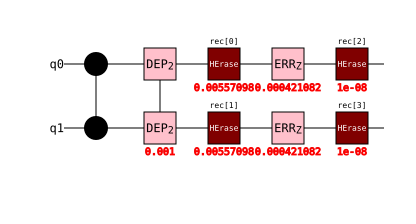

In [15]:
meta_pair = qubits((0, "171", "m", "data"), (1, "171", "m", "data"))

show(YbCircuit(meta_pair, PARAMS).two_qubit_gate("CZ", [0, 1]))

### Reset

The metastable qubit has two reset patterns:

```
pattern b = D . LOSS_m^(reset)                . R    # direct metastable reset
pattern a = D . DECAY_mg . DEP1_gm . FLIP_m   . R    # via the ground manifold
```

Pattern `b`, the default, is short: an ideal reset plus the metastable-reset loss
and the trap loss over the window.

  1  R 0
  2  HERALDED_ERASE(0.006) 0
  3  HERALDED_ERASE(6.66644e-05) 0


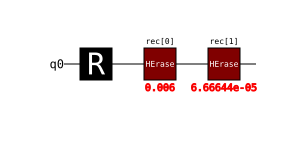

In [16]:
show(YbCircuit(meta, PARAMS).reset_qubit(0, pattern="b"))

Pattern `a` goes through the ground manifold, so it pays for a clock pulse as
well: `FLIP_m` (line 2), then `DEP1_gm` — which after a strict twirl is a `ZERR_m`
plus a loss at `2p/3`, lines 3–4 — then `DECAY_mg` over the reset window (line 5)
and the trap loss (line 6).

  1  R 0
  2  X_ERROR(0.001) 0
  3  Z_ERROR(0.0001) 0
  4  HERALDED_ERASE(6.66667e-05) 0
  5  HERALDED_ERASE(0.001998) 0
  6  HERALDED_ERASE(6.66644e-05) 0


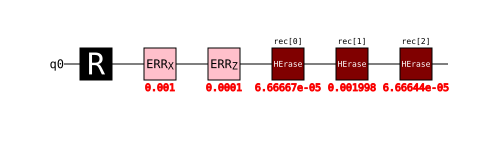

In [17]:
show(YbCircuit(meta, PARAMS).reset_qubit(0, pattern="a"))

### Measurement

```
M~(171, m) = MERR . (D . LOSS_g^(meas) . FLIP_g) . (D . DEP1_gm . D_c)   x2 alternating
```

Reading a metastable qubit means shuttling the population down to the ground
manifold and imaging it, twice. The library does not emit those eight factors
one by one: twirling each separately would throw away the correlations between
them, so the whole sequence is twirled as a unit into a single loss plus Pauli
channel. `get_twirled_171m_measurement_error_rates` evaluates the closed form.

  1  HERALDED_ERASE(0.00216464) 0
  2  PAULI_CHANNEL_1(0.00102478, 2.52282e-05, 0.000199847) 0
  3  HERALDED_ERASE(3.33328e-05) 0
  4  M 0


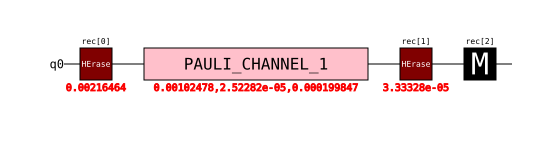

In [18]:
show(YbCircuit(meta, PARAMS).measurement(0))

In [19]:
PARAMS.get_twirled_171m_measurement_error_rates()

{'p_loss': 0.002164640902339187,
 'p_X': 0.0010247784733174784,
 'p_Y': 2.5228184807974093e-05,
 'p_Z': 0.0001998473047411579}

## <sup>171</sup>Yb ground qubit

The ground qubit is the quietest of the three while it waits — nothing decays
*into* the metastable manifold it is not using, so `DECAY_mg` does not act on it
at all and only trap loss remains. It pays for that at gate time instead: to
reach \|r⟩ the atom must first be driven into the metastable manifold, so every
two-qubit gate is bracketed by clock pulses.

### Idling

  1  I 0
  2  Z_ERROR(9.9995e-05) 0
  3  X_ERROR(4.99999e-06) 0
  4  HERALDED_ERASE(3.33328e-05) 0


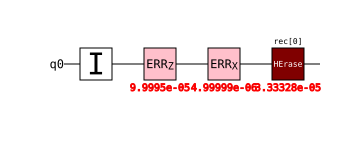

In [20]:
ground = qubits((0, "171", "g", "data"))

show(YbCircuit(ground, PARAMS).idling(0, duration=1e-3))

### Single-qubit gate

Nuclear-spin rotations in the ground manifold are driven directly, so the stack
is just `DEP1_g` and the trap loss over a 1 µs gate.

  1  H 0
  2  DEPOLARIZE1(0.0001) 0
  3  HERALDED_ERASE(3.33333e-08) 0


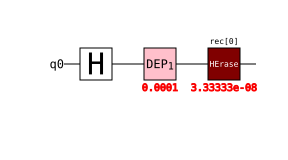

In [21]:
show(YbCircuit(ground, PARAMS).single_qubit_gate("H", 0))

### Two-qubit gate

Lines 1–5 and 11–15 are the clock pulses that move the atom into and back out of
the metastable manifold; lines 6–10 are the `CZ` itself with the same Rydberg
block a metastable qubit would see.

| Line | Channel |
|---|---|
| 1–2 | `DEP1_gm` after a strict twirl: `ZERR` at `p_1^(gm)` plus loss at `2p_1^(gm)/3` |
| 3–4 | `DECAY_mg` over the clock pulse, entered both as a bit flip and as leakage |
| 5 | trap loss over the clock pulse |
| 6–10 | ideal `CZ`, `DEP2_g`, then `LOSS_r + DECAY_rg`, `DECAY_rm`, trap loss |
| 11–15 | the closing clock pulse, same stack as 1–5 |

  1  Z_ERROR(0.0001) 0 1
  2  HERALDED_ERASE(6.66667e-05) 0 1
  3  X_ERROR(9.99995e-06) 0 1
  4  HERALDED_ERASE(9.99995e-06) 0 1
  5  HERALDED_ERASE(3.33333e-07) 0 1
  6  CZ 0 1
  7  DEPOLARIZE2(0.001) 0 1
  8  HERALDED_ERASE(0.00557098) 0 1
  9  Z_ERROR(0.000421082) 0 1
 10  HERALDED_ERASE(1e-08) 0 1
 11  Z_ERROR(0.0001) 0 1
 12  HERALDED_ERASE(6.66667e-05) 0 1
 13  X_ERROR(9.99995e-06) 0 1
 14  HERALDED_ERASE(9.99995e-06) 0 1
 15  HERALDED_ERASE(3.33333e-07) 0 1


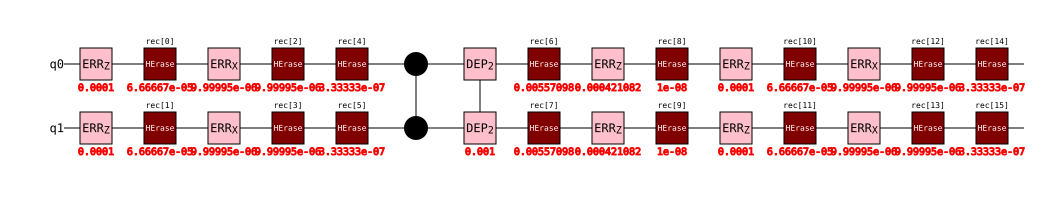

In [22]:
ground_pair = qubits((0, "171", "g", "data"), (1, "171", "g", "ancilla"))

show(YbCircuit(ground_pair, PARAMS).two_qubit_gate("CZ", [0, 1]))

`two_qubit_gate` takes the flat target list Stim uses, so `[0, 1, 2, 3]` is two
parallel `CZ`s, not a four-qubit gate. Parallel gates on the same encoding share
one instruction per channel.

  1  Z_ERROR(0.0001) 0 1 2 3
  2  HERALDED_ERASE(6.66667e-05) 0 1 2 3
  3  X_ERROR(9.99995e-06) 0 1 2 3
  4  HERALDED_ERASE(9.99995e-06) 0 1 2 3
  5  HERALDED_ERASE(3.33333e-07) 0 1 2 3
  6  CZ 0 1 2 3
  7  DEPOLARIZE2(0.001) 0 1 2 3
  8  HERALDED_ERASE(0.00557098) 0 1 2 3
  9  Z_ERROR(0.000421082) 0 1 2 3
 10  HERALDED_ERASE(1e-08) 0 1 2 3
 11  Z_ERROR(0.0001) 0 1 2 3
 12  HERALDED_ERASE(6.66667e-05) 0 1 2 3
 13  X_ERROR(9.99995e-06) 0 1 2 3
 14  HERALDED_ERASE(9.99995e-06) 0 1 2 3
 15  HERALDED_ERASE(3.33333e-07) 0 1 2 3


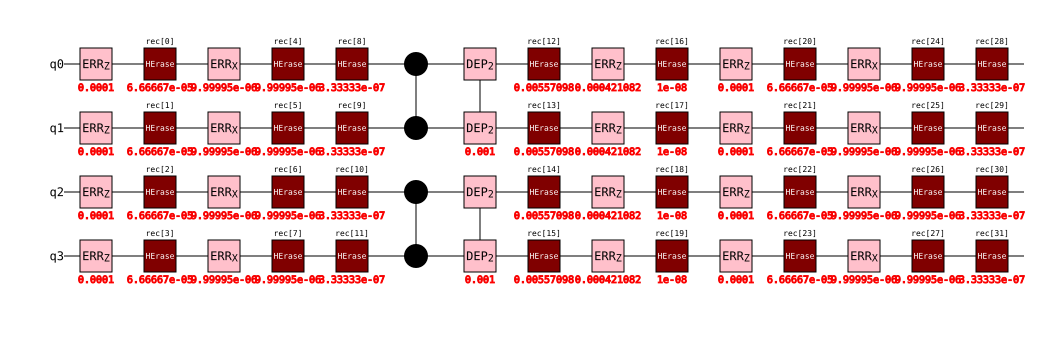

In [23]:
ground_quad = qubits(
    (0, "171", "g", "ancilla"),
    (1, "171", "g", "data"),
    (2, "171", "g", "ancilla"),
    (3, "171", "g", "data"),
)

show(YbCircuit(ground_quad, PARAMS).two_qubit_gate("CZ", [0, 1, 2, 3]))

### Reset

| Line | Channel |
|---|---|
| 1 | the ideal reset |
| 2 | `LOSS_g^(reset)`, loss during preparation and motional reset |
| 3 | `FLIP_g`, a nuclear-spin flip during preparation |
| 4 | trap loss over `t_reset` |

  1  R 0
  2  HERALDED_ERASE(0.001) 0
  3  X_ERROR(0.001) 0
  4  HERALDED_ERASE(6.66644e-05) 0


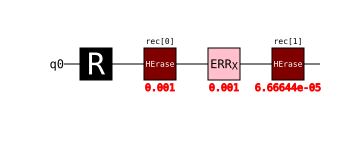

In [24]:
show(YbCircuit(ground, PARAMS).reset_qubit(0))

### Measurement

```
M~(171, g) = MERR . (D . LOSS_g^(meas) . FLIP_g)   x2
```

| Line | Channel |
|---|---|
| 1 | `FLIP_g`, an in-manifold bit flip from the imaging lasers |
| 2 | `LOSS_g^(meas)` plus the loss half of `MERR` |
| 3–4 | the rest of `MERR`: a Pauli part and a loss part |
| 5 | population shelved in the metastable manifold that decays back during the readout window lands in either spin state, i.e. a bit flip at half the decay probability |
| 6 | trap loss over `t_read` |
| 7 | the ideal measurement |

  1  X_ERROR(0.001) 0
  2  HERALDED_ERASE(0.00105) 0
  3  PAULI_CHANNEL_1(2.5e-05, 2.5e-05, 0) 0
  4  HERALDED_ERASE(2.5e-05) 0
  5  X_ERROR(0.00049975) 0
  6  HERALDED_ERASE(3.33328e-05) 0
  7  M 0


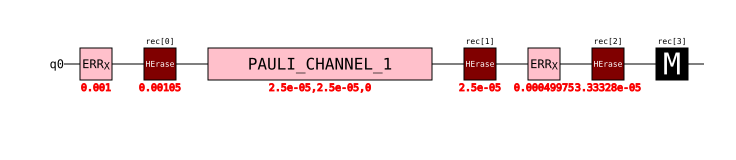

In [25]:
show(YbCircuit(ground, PARAMS).measurement(0))

## Dual-isotope and mixed gates

A `CZ` between different encodings takes `DEP2_dual` for the pair, and then each
atom gets its own decay block. The whole point of the dual-isotope layout is
that the two species are not interchangeable.

### <sup>171</sup>Yb-m with <sup>174</sup>Yb

  1  CZ 0 1
  2  DEPOLARIZE2(0.001) 0 1
  3  HERALDED_ERASE(0.00557098) 0
  4  Z_ERROR(0.000421082) 0
  5  HERALDED_ERASE(1e-08) 0
  6  HERALDED_ERASE(0.00305084) 1
  7  X_ERROR(0.00252014) 1
  8  Z_ERROR(0.000421082) 1
  9  HERALDED_ERASE(1e-08) 1


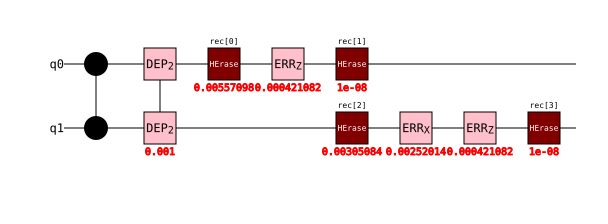

In [26]:
dual_m = qubits((0, "171", "m", "data"), (1, "174", "gm", "ancilla"))

show(YbCircuit(dual_m, PARAMS).two_qubit_gate("CZ", [0, 1]))

### <sup>171</sup>Yb-g with <sup>174</sup>Yb

The g qubit needs its clock bracket, and the partner is not free to sit still
while that happens: the <sup>174</sup>Yb atom idles for the clock-pulse duration
on either side (lines 6–8 and 23–25).

In [27]:
dual_g = qubits((0, "171", "g", "data"), (1, "174", "gm", "ancilla"))

show(YbCircuit(dual_g, PARAMS).two_qubit_gate("CZ", [0, 1]), diagram=False)

  1  Z_ERROR(0.0001) 0
  2  HERALDED_ERASE(6.66667e-05) 0
  3  X_ERROR(9.99995e-06) 0
  4  HERALDED_ERASE(9.99995e-06) 0
  5  HERALDED_ERASE(3.33333e-07) 0
  6  I 1
  7  PAULI_CHANNEL_1(1.25e-07, 1.25e-07, 8.74999e-07) 1
  8  HERALDED_ERASE(3.33333e-07) 1
  9  CZ 0 1
 10  DEPOLARIZE2(0.001) 0 1
 11  HERALDED_ERASE(0.00557098) 0
 12  Z_ERROR(0.000421082) 0
 13  HERALDED_ERASE(1e-08) 0
 14  HERALDED_ERASE(0.00305084) 1
 15  X_ERROR(0.00252014) 1
 16  Z_ERROR(0.000421082) 1
 17  HERALDED_ERASE(1e-08) 1
 18  Z_ERROR(0.0001) 0
 19  HERALDED_ERASE(6.66667e-05) 0
 20  X_ERROR(9.99995e-06) 0
 21  HERALDED_ERASE(9.99995e-06) 0
 22  HERALDED_ERASE(3.33333e-07) 0
 23  I 1
 24  PAULI_CHANNEL_1(1.25e-07, 1.25e-07, 8.74999e-07) 1
 25  HERALDED_ERASE(3.33333e-07) 1


### <sup>171</sup>Yb-g with <sup>171</sup>Yb-m

In [28]:
same_isotope_mixed = qubits((0, "171", "g", "data"), (1, "171", "m", "data"))

show(YbCircuit(same_isotope_mixed, PARAMS).two_qubit_gate("CZ", [0, 1]), diagram=False)

  1  Z_ERROR(0.0001) 0
  2  HERALDED_ERASE(6.66667e-05) 0
  3  X_ERROR(9.99995e-06) 0
  4  HERALDED_ERASE(9.99995e-06) 0
  5  HERALDED_ERASE(3.33333e-07) 0
  6  I 1
  7  Z_ERROR(9.99999e-07) 1
  8  X_ERROR(5e-08) 1
  9  HERALDED_ERASE(9.99995e-06) 1
 10  HERALDED_ERASE(3.33333e-07) 1
 11  CZ 0 1
 12  DEPOLARIZE2(0.001) 0 1
 13  HERALDED_ERASE(0.00557098) 0 1
 14  Z_ERROR(0.000421082) 0 1
 15  HERALDED_ERASE(1e-08) 0 1
 16  Z_ERROR(0.0001) 0
 17  HERALDED_ERASE(6.66667e-05) 0
 18  X_ERROR(9.99995e-06) 0
 19  HERALDED_ERASE(9.99995e-06) 0
 20  HERALDED_ERASE(3.33333e-07) 0
 21  I 1
 22  Z_ERROR(9.99999e-07) 1
 23  X_ERROR(5e-08) 1
 24  HERALDED_ERASE(9.99995e-06) 1
 25  HERALDED_ERASE(3.33333e-07) 1


### Mixed target lists

Every operation accepts a list of qubits and groups them by encoding internally,
emitting one instruction per (channel, encoding) rather than one per qubit.
Below, qubits 0 and 3 are <sup>174</sup>Yb, 1 is <sup>171</sup>Yb-m and 2 is
<sup>171</sup>Yb-g: the twirled damping channel covers `0 3` in one instruction,
while the trap loss — same rate for all three encodings here — covers all four.

  1  I 0 1 2 3
  2  PAULI_CHANNEL_1(1.24997e-05, 1.24997e-05, 8.74903e-05) 0 3
  3  Z_ERROR(9.9995e-05) 1
  4  X_ERROR(4.99999e-06) 1
  5  HERALDED_ERASE(0.0009995) 1
  6  Z_ERROR(9.9995e-05) 2
  7  X_ERROR(4.99999e-06) 2
  8  HERALDED_ERASE(3.33328e-05) 0 3 1 2


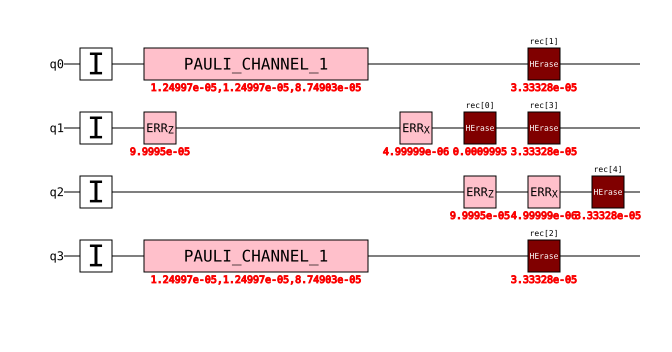

In [29]:
mixed = qubits(
    (0, "174", "gm", "data"),
    (1, "171", "m", "data"),
    (2, "171", "g", "data"),
    (3, "174", "gm", "data"),
)

show(YbCircuit(mixed, PARAMS).idling([0, 1, 2, 3], duration=1e-3))

In [30]:
show(YbCircuit(mixed, PARAMS).two_qubit_gate("CZ", [0, 1, 2, 3]), diagram=False)

  1  Z_ERROR(0.0001) 2
  2  HERALDED_ERASE(6.66667e-05) 2
  3  X_ERROR(9.99995e-06) 2
  4  HERALDED_ERASE(9.99995e-06) 2
  5  HERALDED_ERASE(3.33333e-07) 2
  6  I 0 1 3
  7  PAULI_CHANNEL_1(1.25e-07, 1.25e-07, 8.74999e-07) 0 3
  8  Z_ERROR(9.99999e-07) 1
  9  X_ERROR(5e-08) 1
 10  HERALDED_ERASE(9.99995e-06) 1
 11  HERALDED_ERASE(3.33333e-07) 0 3 1
 12  CZ 0 1 2 3
 13  DEPOLARIZE2(0.001) 0 1 2 3
 14  HERALDED_ERASE(0.00557098) 1 2
 15  Z_ERROR(0.000421082) 1 2
 16  HERALDED_ERASE(1e-08) 1 2
 17  HERALDED_ERASE(0.00305084) 0 3
 18  X_ERROR(0.00252014) 0 3
 19  Z_ERROR(0.000421082) 0 3
 20  HERALDED_ERASE(1e-08) 0 3
 21  Z_ERROR(0.0001) 2
 22  HERALDED_ERASE(6.66667e-05) 2
 23  X_ERROR(9.99995e-06) 2
 24  HERALDED_ERASE(9.99995e-06) 2
 25  HERALDED_ERASE(3.33333e-07) 2
 26  I 0 1 3
 27  PAULI_CHANNEL_1(1.25e-07, 1.25e-07, 8.74999e-07) 0 3
 28  Z_ERROR(9.99999e-07) 1
 29  X_ERROR(5e-08) 1
 30  HERALDED_ERASE(9.99995e-06) 1
 31  HERALDED_ERASE(3.33333e-07) 0 3 1


## Transport

```
I~(trans) = LOSS^(hand) . D . I~ . LOSS^(hand) . I(trans)
```

Moving an atom means handing it from a static trap to a movable one, shuttling
it, and handing it back. Each handover has its own loss probability; between
them the atom simply idles, so the shuttling noise is the idling stack evaluated
at the transport time.

`transport` takes a distance in metres and converts it with
`t_move(l) = 2 sqrt(l / a)`; `transport_with_time` takes the time directly, for
when the schedule was worked out elsewhere.

t_move(13 um) = 97.2 us
t_hand        = 200.0 us
  1  I 0 3
  2  HERALDED_ERASE(0.001) 0 3
  3  PAULI_CHANNEL_1(1.21543e-06, 1.21543e-06, 8.50793e-06) 0 3
  4  HERALDED_ERASE(3.24114e-06) 0 3
  5  HERALDED_ERASE(0.001) 0 3


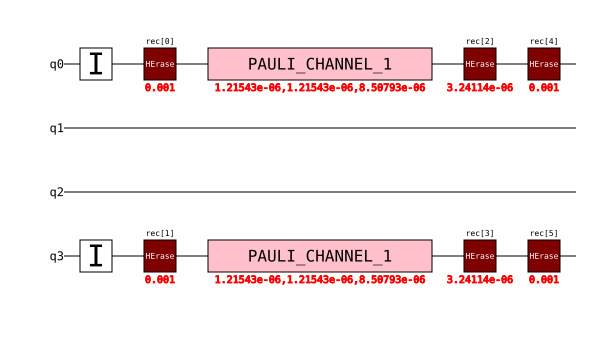

In [31]:
print(f"t_move(13 um) = {PARAMS.transportation_time(13e-6) * 1e6:.1f} us")
print(f"t_hand        = {PARAMS.t_hand * 1e6:.1f} us")

show(YbCircuit(mixed, PARAMS).transport([0, 3], distance=13e-6))

Loss dominates. Lines 2 and 5 are the handovers at `p^(hand) = 10⁻³` each, two
orders of magnitude larger than anything the atom picked up during the 97 µs
flight in between.

The same call on the <sup>171</sup>Yb qubits swaps the shuttling noise for the
`ZERR`/`XERR` pair, and adds the metastable leakage on the m qubit (line 5) that
the g qubit does not pay.

  1  I 1 2
  2  HERALDED_ERASE(0.001) 1 2
  3  Z_ERROR(9.7234e-06) 1
  4  X_ERROR(4.86172e-07) 1
  5  HERALDED_ERASE(9.72298e-05) 1
  6  Z_ERROR(9.7234e-06) 2
  7  X_ERROR(4.86172e-07) 2
  8  HERALDED_ERASE(3.24114e-06) 1 2
  9  HERALDED_ERASE(0.001) 1 2


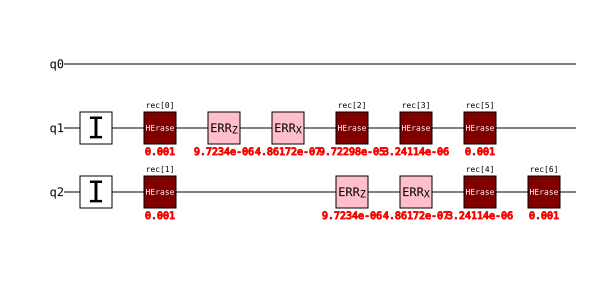

In [32]:
show(YbCircuit(mixed, PARAMS).transport([1, 2], distance=13e-6))

  1  I 0
  2  HERALDED_ERASE(0.001) 0
  3  PAULI_CHANNEL_1(6.24992e-06, 6.24992e-06, 4.37476e-05) 0
  4  HERALDED_ERASE(1.66665e-05) 0
  5  HERALDED_ERASE(0.001) 0


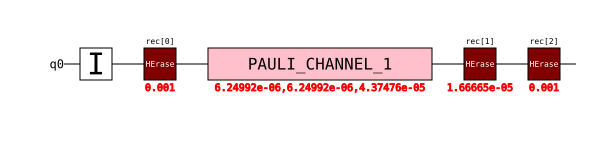

In [33]:
show(YbCircuit(mixed, PARAMS).transport_with_time(0, transport_time=500e-6))

`handover` is one half of that — the handover loss plus idling over `t_hand` —
and is what the transport readout protocol composes internally.

  1  I 0 2
  2  PAULI_CHANNEL_1(2.49999e-06, 2.49999e-06, 1.74996e-05) 0
  3  Z_ERROR(1.99998e-05) 2
  4  X_ERROR(9.99999e-07) 2
  5  HERALDED_ERASE(6.66664e-06) 0 2
  6  HERALDED_ERASE(0.001) 0 2


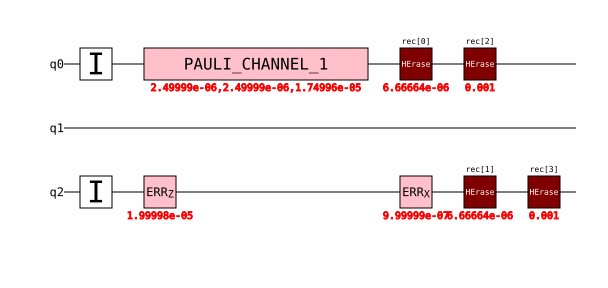

In [34]:
show(YbCircuit(mixed, PARAMS).handover([0, 2]))

## Shelving

`shelve` drives a <sup>171</sup>Yb-g qubit into the metastable manifold, where
the imaging light used to read another atom cannot reach it; `unshelve` brings it
back. Both are one clock excitation, so the noise is the same bracket a
<sup>171</sup>Yb-g two-qubit gate pays.

Only the ground qubit can be shelved — for the other encodings the metastable
manifold is where the qubit already lives.

  1  I 0 1
  2  Z_ERROR(0.0001) 0 1
  3  HERALDED_ERASE(6.66667e-05) 0 1
  4  X_ERROR(9.99995e-06) 0 1
  5  HERALDED_ERASE(9.99995e-06) 0 1
  6  HERALDED_ERASE(3.33333e-07) 0 1
  7  I 0 1
  8  Z_ERROR(0.0001) 0 1
  9  HERALDED_ERASE(6.66667e-05) 0 1
 10  X_ERROR(9.99995e-06) 0 1
 11  HERALDED_ERASE(9.99995e-06) 0 1
 12  HERALDED_ERASE(3.33333e-07) 0 1


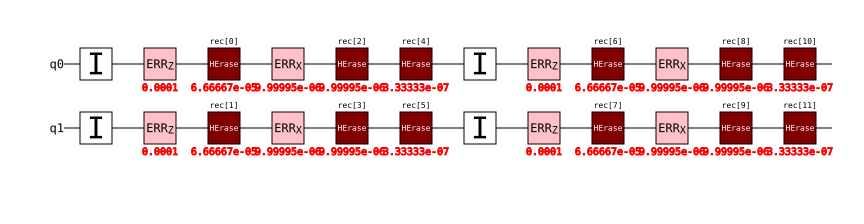

In [35]:
shelvable = qubits((0, "171", "g", "data"), (1, "171", "g", "data"))

circuit = YbCircuit(shelvable, PARAMS)
circuit.shelve([0, 1])
circuit.unshelve([0, 1])
show(circuit)

In [36]:
try:
    YbCircuit(clock, PARAMS).shelve(0)
except NotImplementedError as error:
    print(f"NotImplementedError: {error}")

NotImplementedError: shelve is not yet implemented for (174, gm)


## Selective measurement

Reading an ancilla mid-circuit is the operation that hurts the data qubits, and
there are three ways to arrange it. `selective_measurement` takes the qubits
being read and the qubits that must survive, and inserts a different stack for
each protocol.

### `in_place_direct` (the default)

The ancilla is imaged where it sits: lines 1–7 are exactly the
<sup>174</sup>Yb measurement stack from earlier, and the data qubits idle through
the readout window (lines 8–14). That idling is the whole cost — 1 ms of it,
which for the metastable data qubit means a `HERALDED_ERASE` at 10⁻³.

  1  HERALDED_ERASE(0.001) 0
  2  PAULI_CHANNEL_1(1.24997e-05, 1.24997e-05, 0) 0
  3  DEPOLARIZE1(0.0001) 0
  4  HERALDED_ERASE(9.999e-05) 0
  5  PAULI_CHANNEL_1(2.5005e-05, 2.5005e-05, 0) 0
  6  HERALDED_ERASE(3.33328e-05) 0
  7  M 0
  8  I 1 2
  9  Z_ERROR(9.9995e-05) 1
 10  X_ERROR(4.99999e-06) 1
 11  HERALDED_ERASE(0.0009995) 1
 12  Z_ERROR(9.9995e-05) 2
 13  X_ERROR(4.99999e-06) 2
 14  HERALDED_ERASE(3.33328e-05) 1 2


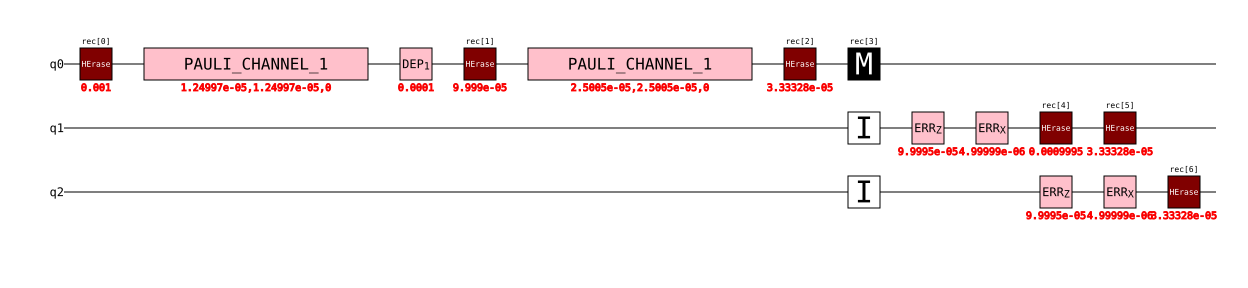

In [37]:
readout = qubits(
    (0, "174", "gm", "ancilla"),  # measured
    (1, "171", "m", "data"),      # must survive
    (2, "171", "g", "data"),
)

circuit = YbCircuit(readout, PARAMS)
circuit.selective_measurement(
    measured_qubits=[0],
    unmeasured_qubits=[1, 2],
    protocol="in_place_direct",
)
show(circuit)

The model also carries a scattered-light depolarising term for
<sup>171</sup>Yb qubits idling while the other isotope is imaged. It is not part
of the paper's channel set and both presets hold it at zero, which is why no
`DEPOLARIZE1` appears on qubits 1 and 2 above. Set it and it shows up:

In [38]:
scattering = NoiseModelParameters()
scattering.set_parameters(p_depol_meas_idling_m=1e-3, p_depol_meas_idling_g=1e-3)

circuit = YbCircuit(readout, scattering)
circuit.selective_measurement(
    measured_qubits=[0],
    unmeasured_qubits=[1, 2],
    protocol="in_place_direct",
)
show(circuit, diagram=False)

  1  HERALDED_ERASE(0.001) 0
  2  PAULI_CHANNEL_1(1.24997e-05, 1.24997e-05, 0) 0
  3  DEPOLARIZE1(0.0001) 0
  4  HERALDED_ERASE(9.999e-05) 0
  5  PAULI_CHANNEL_1(2.5005e-05, 2.5005e-05, 0) 0
  6  HERALDED_ERASE(3.33328e-05) 0
  7  M 0
  8  I 1 2
  9  Z_ERROR(9.9995e-05) 1
 10  X_ERROR(4.99999e-06) 1
 11  HERALDED_ERASE(0.0009995) 1
 12  Z_ERROR(9.9995e-05) 2
 13  X_ERROR(4.99999e-06) 2
 14  HERALDED_ERASE(3.33328e-05) 1 2
 15  DEPOLARIZE1(0.001) 1 2


### `transport`

The ancilla is shuttled to a readout zone and back, so nothing scatters onto the
data qubits — but the trip costs eight handover-loss events (one per `handover`,
two per `transport_with_time` for the traps at either end of the flight) and the
data qubits idle through all of it. The one-way distance comes from the code
distance, since that is what sets how far the edge of the patch is from the
readout zone.

In [39]:
print(f"one-way distance, d=5: {PARAMS.readout_transport_one_way_distance(5) * 1e6:.1f} um")
print(f"round trip time, d=5:  {PARAMS.readout_transport_round_trip_time(5) * 1e3:.2f} ms")

circuit = YbCircuit(readout, PARAMS)
circuit.selective_measurement(
    measured_qubits=[0],
    unmeasured_qubits=[1, 2],
    protocol="transport",
    code_distance=5,
)
show(circuit, diagram=False)

one-way distance, d=5: 115.0 um
round trip time, d=5:  2.38 ms
  1  I 0
  2  PAULI_CHANNEL_1(2.49999e-06, 2.49999e-06, 1.74996e-05) 0
  3  HERALDED_ERASE(6.66664e-06) 0
  4  HERALDED_ERASE(0.001) 0
  5  I 1 2
  6  Z_ERROR(1.99998e-05) 1
  7  X_ERROR(9.99999e-07) 1
  8  HERALDED_ERASE(0.00019998) 1
  9  Z_ERROR(1.99998e-05) 2
 10  X_ERROR(9.99999e-07) 2
 11  HERALDED_ERASE(6.66664e-06) 1 2
 12  I 0
 13  HERALDED_ERASE(0.001) 0
 14  PAULI_CHANNEL_1(3.61497e-06, 3.61497e-06, 2.53041e-05) 0
 15  HERALDED_ERASE(9.63994e-06) 0
 16  HERALDED_ERASE(0.001) 0
 17  I 1 2
 18  Z_ERROR(2.89195e-05) 1
 19  X_ERROR(1.446e-06) 1
 20  HERALDED_ERASE(0.000289158) 1
 21  Z_ERROR(2.89195e-05) 2
 22  X_ERROR(1.446e-06) 2
 23  HERALDED_ERASE(9.63994e-06) 1 2
 24  I 0
 25  PAULI_CHANNEL_1(2.49999e-06, 2.49999e-06, 1.74996e-05) 0
 26  HERALDED_ERASE(6.66664e-06) 0
 27  HERALDED_ERASE(0.001) 0
 28  I 1 2
 29  Z_ERROR(1.99998e-05) 1
 30  X_ERROR(9.99999e-07) 1
 31  HERALDED_ERASE(0.00019998) 1
 32  Z_ERROR(1.99

### `shelving`

The data qubits are hidden in the metastable manifold instead: one clock pulse in
(lines 1–6), the readout, one clock pulse out (lines 21–26). They still idle
through the readout window (lines 17–20), and the ancilla idles through the clock
pulses in turn (lines 7–9 and 27–29), but no atom moves.
<sup>171</sup>Yb-g data qubits only.

In [40]:
shelving_readout = qubits(
    (0, "174", "gm", "ancilla"),
    (1, "171", "g", "data"),
    (2, "171", "g", "data"),
)

circuit = YbCircuit(shelving_readout, PARAMS)
circuit.selective_measurement(
    measured_qubits=[0],
    unmeasured_qubits=[1, 2],
    protocol="shelving",
)
show(circuit, diagram=False)

  1  I 1 2
  2  Z_ERROR(0.0001) 1 2
  3  HERALDED_ERASE(6.66667e-05) 1 2
  4  X_ERROR(9.99995e-06) 1 2
  5  HERALDED_ERASE(9.99995e-06) 1 2
  6  HERALDED_ERASE(3.33333e-07) 1 2
  7  I 0
  8  PAULI_CHANNEL_1(1.25e-07, 1.25e-07, 8.74999e-07) 0
  9  HERALDED_ERASE(3.33333e-07) 0
 10  HERALDED_ERASE(0.001) 0
 11  PAULI_CHANNEL_1(1.24997e-05, 1.24997e-05, 0) 0
 12  DEPOLARIZE1(0.0001) 0
 13  HERALDED_ERASE(9.999e-05) 0
 14  PAULI_CHANNEL_1(2.5005e-05, 2.5005e-05, 0) 0
 15  HERALDED_ERASE(3.33328e-05) 0
 16  M 0
 17  I 1 2
 18  Z_ERROR(9.9995e-05) 1 2
 19  X_ERROR(4.99999e-06) 1 2
 20  HERALDED_ERASE(3.33328e-05) 1 2
 21  I 1 2
 22  Z_ERROR(0.0001) 1 2
 23  HERALDED_ERASE(6.66667e-05) 1 2
 24  X_ERROR(9.99995e-06) 1 2
 25  HERALDED_ERASE(9.99995e-06) 1 2
 26  HERALDED_ERASE(3.33333e-07) 1 2
 27  I 0
 28  PAULI_CHANNEL_1(1.25e-07, 1.25e-07, 8.74999e-07) 0
 29  HERALDED_ERASE(3.33333e-07) 0


The three protocols trade different resources, which shows up directly in how
many channels each one emits.

In [41]:
for protocol, extra in [
    ("in_place_direct", {}),
    ("transport", {"code_distance": 5}),
    ("shelving", {}),
]:
    circuit = YbCircuit(shelving_readout, PARAMS)
    circuit.selective_measurement(
        measured_qubits=[0], unmeasured_qubits=[1, 2], protocol=protocol, **extra
    )
    print(f"{protocol:16s} {channel_counts(circuit)}")

in_place_direct  {'DEPOLARIZE1': 1, 'HERALDED_ERASE': 4, 'I': 1, 'M': 1, 'PAULI_CHANNEL_1': 2, 'X_ERROR': 1, 'Z_ERROR': 1}
transport        {'DEPOLARIZE1': 1, 'HERALDED_ERASE': 24, 'I': 13, 'M': 1, 'PAULI_CHANNEL_1': 8, 'X_ERROR': 7, 'Z_ERROR': 7}
shelving         {'DEPOLARIZE1': 1, 'HERALDED_ERASE': 12, 'I': 5, 'M': 1, 'PAULI_CHANNEL_1': 4, 'X_ERROR': 3, 'Z_ERROR': 3}


## From an ideal Stim program to a noisy one

`YbNoiseModel` is the usual entry point. It works in two passes: build the ideal
circuit while recording an operation log, then replay that log with noise
enabled. Nothing is pattern-matched on the Stim text — the noise is attached to
the high-level operation the instruction was recognised as.

In [42]:
program = stim.Circuit('''
    R 0 1
    TICK
    H 0
    TICK
    CZ 0 1
    TICK
    M 0
    TICK
    DETECTOR rec[-1]
''')

pair = qubits((0, "174", "gm", "ancilla"), (1, "174", "gm", "data"))
model = YbNoiseModel(PARAMS)

### Pass 1: the ideal circuit

Note the `I 1` instructions. `TICK` marks a moment boundary, and a qubit that is
not touched in a moment is not idle in the laboratory — it sits there while the
others are driven. `from_stim` inserts explicit idling for those qubits, with the
duration of the longest operation in the moment.

  1  R 0 1
  2  TICK
  3  H 0
  4  I 1
  5  TICK
  6  CZ 0 1
  7  TICK
  8  M 0
  9  I 1
 10  TICK
 11  DETECTOR rec[-1]


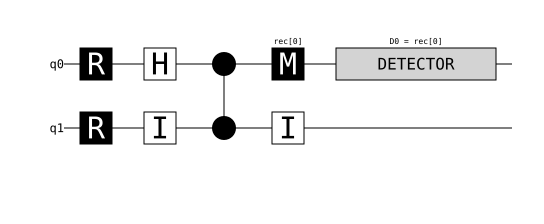

In [43]:
show(model.noiseless_circuit(program, pair))

### Pass 2: replay with noise

Every stack from the sections above, in place: lines 1–4 the reset, 6–12 the `H`
with the spectator's idling, 14–19 the `CZ`, 21–30 the measurement with the
spectator idling through `t_read`. The `TICK`s survive as moment boundaries.

The last line is worth a look. `HERALDED_ERASE` writes a herald into the
measurement record, so the `rec[-1]` of the ideal program no longer points at the
`M`: the model rewrites the lookback to `rec[-2]`. Detectors and observables are
re-indexed as the circuit grows, so a detector annotation written against the
ideal circuit keeps its meaning.

  1  R 0 1
  2  HERALDED_ERASE(0.001) 0 1
  3  PAULI_CHANNEL_1(2.49988e-05, 2.49988e-05, 0) 0 1
  4  HERALDED_ERASE(6.66644e-05) 0 1
  5  TICK
  6  H 0
  7  DEPOLARIZE1(0.0001) 0
  8  PAULI_CHANNEL_1(1.25e-06, 1.25e-06, 0) 0
  9  HERALDED_ERASE(3.33333e-06) 0
 10  I 1
 11  PAULI_CHANNEL_1(1.25e-06, 1.25e-06, 8.7499e-06) 1
 12  HERALDED_ERASE(3.33333e-06) 1
 13  TICK
 14  CZ 0 1
 15  DEPOLARIZE2(0.001) 0 1
 16  HERALDED_ERASE(0.00305084) 0 1
 17  X_ERROR(0.00252014) 0 1
 18  Z_ERROR(0.000421082) 0 1
 19  HERALDED_ERASE(1e-08) 0 1
 20  TICK
 21  HERALDED_ERASE(0.001) 0
 22  PAULI_CHANNEL_1(1.24997e-05, 1.24997e-05, 0) 0
 23  DEPOLARIZE1(0.0001) 0
 24  HERALDED_ERASE(9.999e-05) 0
 25  PAULI_CHANNEL_1(2.5005e-05, 2.5005e-05, 0) 0
 26  HERALDED_ERASE(3.33328e-05) 0
 27  M 0
 28  I 1
 29  PAULI_CHANNEL_1(1.24997e-05, 1.24997e-05, 8.74903e-05) 1
 30  HERALDED_ERASE(3.33328e-05) 1
 31  TICK
 32  DETECTOR rec[-2]


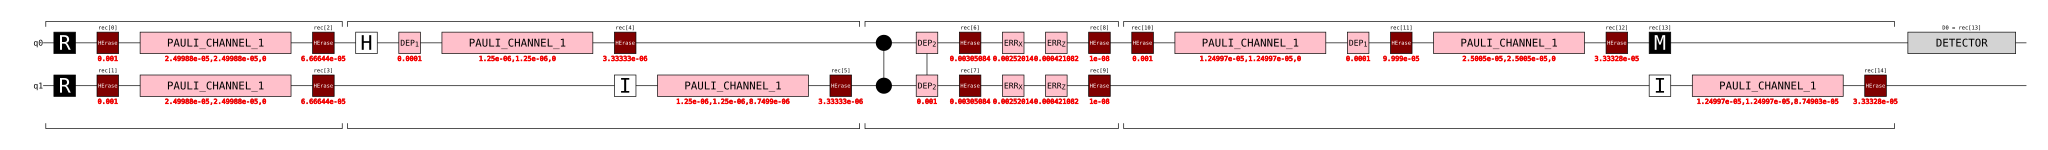

In [44]:
show(model.noisy_circuit(program, pair))

Because the inserted idling inherits the moment duration, the cost of being a
spectator depends on what the other qubits were doing: a <sup>174</sup>Yb clock
pulse takes 100 µs, a `CZ` 300 ns, a readout 1 ms.

In [45]:
for gate_time in ("t_1Q", "t_2Q", "t_read", "t_reset"):
    seconds = PARAMS.get_gate_time(gate_time, "174", "gm")
    print(f"174Yb {gate_time:8s} {seconds * 1e6:9.2f} us")

174Yb t_1Q        100.00 us
174Yb t_2Q          0.30 us
174Yb t_read     1000.00 us
174Yb t_reset    2000.00 us


### Swapping the readout protocol

`noisy_circuit` can substitute a selective-readout protocol for every plain
measurement in the program, which is how a surface-code round is switched from
in-place readout to transport or shelving without touching the ideal circuit.

In [46]:
ground_data = qubits((0, "174", "gm", "ancilla"), (1, "171", "g", "data"))

for protocol in ("in_place_direct", "transport", "shelving"):
    extra = {"code_distance": 5} if protocol == "transport" else {}
    noisy = model.noisy_circuit(program, ground_data, readout_protocol=protocol, **extra)
    print(f"{protocol:16s} {channel_counts(noisy)}")

in_place_direct  {'CZ': 1, 'DEPOLARIZE1': 2, 'DEPOLARIZE2': 1, 'DETECTOR': 1, 'H': 1, 'HERALDED_ERASE': 22, 'I': 4, 'M': 1, 'PAULI_CHANNEL_1': 6, 'R': 1, 'TICK': 4, 'X_ERROR': 6, 'Z_ERROR': 6}
transport        {'CZ': 1, 'DEPOLARIZE1': 2, 'DEPOLARIZE2': 1, 'DETECTOR': 1, 'H': 1, 'HERALDED_ERASE': 42, 'I': 16, 'M': 1, 'PAULI_CHANNEL_1': 12, 'R': 1, 'TICK': 4, 'X_ERROR': 12, 'Z_ERROR': 12}
shelving         {'CZ': 1, 'DEPOLARIZE1': 2, 'DEPOLARIZE2': 1, 'DETECTOR': 1, 'H': 1, 'HERALDED_ERASE': 30, 'I': 8, 'M': 1, 'PAULI_CHANNEL_1': 8, 'R': 1, 'TICK': 4, 'X_ERROR': 8, 'Z_ERROR': 8}


In [47]:
noisy = model.noisy_circuit(
    program, ground_data, readout_protocol="shelving"
)
show(noisy, diagram=False)

  1  R 0 1
  2  HERALDED_ERASE(0.001) 0
  3  PAULI_CHANNEL_1(2.49988e-05, 2.49988e-05, 0) 0
  4  HERALDED_ERASE(6.66644e-05) 0
  5  HERALDED_ERASE(0.001) 1
  6  X_ERROR(0.001) 1
  7  HERALDED_ERASE(6.66644e-05) 1
  8  TICK
  9  H 0
 10  DEPOLARIZE1(0.0001) 0
 11  PAULI_CHANNEL_1(1.25e-06, 1.25e-06, 0) 0
 12  HERALDED_ERASE(3.33333e-06) 0
 13  I 1
 14  Z_ERROR(9.99995e-06) 1
 15  X_ERROR(5e-07) 1
 16  HERALDED_ERASE(3.33333e-06) 1
 17  TICK
 18  Z_ERROR(0.0001) 1
 19  HERALDED_ERASE(6.66667e-05) 1
 20  X_ERROR(9.99995e-06) 1
 21  HERALDED_ERASE(9.99995e-06) 1
 22  HERALDED_ERASE(3.33333e-07) 1
 23  I 0
 24  PAULI_CHANNEL_1(1.25e-07, 1.25e-07, 8.74999e-07) 0
 25  HERALDED_ERASE(3.33333e-07) 0
 26  CZ 0 1
 27  DEPOLARIZE2(0.001) 0 1
 28  HERALDED_ERASE(0.00557098) 1
 29  Z_ERROR(0.000421082) 1
 30  HERALDED_ERASE(1e-08) 1
 31  HERALDED_ERASE(0.00305084) 0
 32  X_ERROR(0.00252014) 0
 33  Z_ERROR(0.000421082) 0
 34  HERALDED_ERASE(1e-08) 0
 35  Z_ERROR(0.0001) 1
 36  HERALDED_ERASE(6.66667e

### Building a noisy circuit

`YbCircuit` with `noise_enabled=False` records the same operation log, so a
circuit can be built ideally and then noised — with different parameters, as many
times as needed. This is also the path for constructions Stim's text format
cannot express, such as transport.

  1  R 0 1
  2  H 0
  3  CZ 0 1
  4  I 0 1
  5  M 0


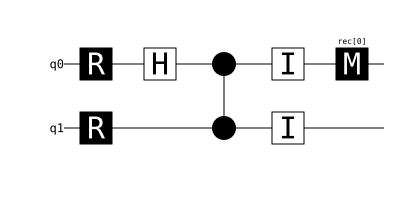

In [48]:
ideal = YbCircuit(pair, PARAMS, noise_enabled=False)
ideal.reset_qubit([0, 1])
ideal.single_qubit_gate("H", 0)
ideal.two_qubit_gate("CZ", [0, 1])
ideal.transport([0, 1], distance=13e-6)
ideal.measurement(0)

show(ideal)

In [49]:
show(ideal.with_noise(), diagram=False)

  1  R 0 1
  2  HERALDED_ERASE(0.001) 0 1
  3  PAULI_CHANNEL_1(2.49988e-05, 2.49988e-05, 0) 0 1
  4  HERALDED_ERASE(6.66644e-05) 0 1
  5  H 0
  6  DEPOLARIZE1(0.0001) 0
  7  PAULI_CHANNEL_1(1.25e-06, 1.25e-06, 0) 0
  8  HERALDED_ERASE(3.33333e-06) 0
  9  CZ 0 1
 10  DEPOLARIZE2(0.001) 0 1
 11  HERALDED_ERASE(0.00305084) 0 1
 12  X_ERROR(0.00252014) 0 1
 13  Z_ERROR(0.000421082) 0 1
 14  HERALDED_ERASE(1e-08) 0 1
 15  I 0 1
 16  HERALDED_ERASE(0.001) 0 1
 17  PAULI_CHANNEL_1(1.21543e-06, 1.21543e-06, 8.50793e-06) 0 1
 18  HERALDED_ERASE(3.24114e-06) 0 1
 19  HERALDED_ERASE(0.001) 0 1 0
 20  PAULI_CHANNEL_1(1.24997e-05, 1.24997e-05, 0) 0
 21  DEPOLARIZE1(0.0001) 0
 22  HERALDED_ERASE(9.999e-05) 0
 23  PAULI_CHANNEL_1(2.5005e-05, 2.5005e-05, 0) 0
 24  HERALDED_ERASE(3.33328e-05) 0
 25  M 0


`without_noise` goes the other way, stripping the channels back out. Removing
`HERALDED_ERASE` leaves `MPAD` placeholders behind, because the herald occupied a
measurement record that later `rec[-k]` offsets are counted against; pass
`removed_MPADs=True` once nothing refers to them.

In [50]:
noisy = ideal.with_noise()
print(channel_counts(noisy.without_noise()))
print(channel_counts(noisy.without_noise(removed_MPADs=True)))

{'CZ': 1, 'H': 1, 'I': 1, 'M': 1, 'MPAD': 4, 'R': 1}
{'CZ': 1, 'H': 1, 'I': 1, 'M': 1, 'R': 1}


## Tuning of noise parameters

Every probability in the listings above traces back to a `NoiseModelParameters`
field or a rate plus a duration. Reading them per encoding is usually clearer
than reading the flat tagged names.

In [51]:
view = PARAMS.for_qubit("171", "m")
print(f"p_1        {view.p_1}       # DEP1_m, the single-qubit depolarising rate")
print(f"p_2        {view.p_2}       # DEP2_m")
print(f"gamma_Z    {view.gamma_Z}   # 1/T_2")
print(f"gamma_X    {view.gamma_X}   # 1/T_1")
print(f"gamma_mg   {view.gamma_mg}  # metastable -> ground decay")
print(f"p_hand     {view.p_hand}    # loss per handover")

p_1        0.0001       # DEP1_m, the single-qubit depolarising rate
p_2        0.001       # DEP2_m
gamma_Z    0.1   # 1/T_2
gamma_X    0.005   # 1/T_1
gamma_mg   1.0  # metastable -> ground decay
p_hand     0.001    # loss per handover


`set_parameters` validates and writes; `rescale_error_params` scales every
probability and rate at once — every `p_*` and `gamma_*`, leaving the timings
alone — which is the usual way to sweep a device towards or away from threshold.

It returns a rescaled copy rather than editing in place unless `inplace=True` is
passed, so the return value is the thing to keep.

In [52]:
for scale in (1.0, 0.5, 0.1):
    scaled = NoiseModelParameters().rescale_error_params(scale)
    circuit = YbCircuit(clock_pair, scaled).two_qubit_gate("CZ", [0, 1])
    print(f"scale = {scale}")
    show(circuit, diagram=False)
    print()

scale = 1.0
  1  CZ 0 1
  2  DEPOLARIZE2(0.001) 0 1
  3  HERALDED_ERASE(0.00305084) 0 1
  4  X_ERROR(0.00252014) 0 1
  5  Z_ERROR(0.000421082) 0 1
  6  HERALDED_ERASE(1e-08) 0 1

scale = 0.5
  1  CZ 0 1
  2  DEPOLARIZE2(0.0005) 0 1
  3  HERALDED_ERASE(0.00152771) 0 1
  4  X_ERROR(0.00126004) 0 1
  5  Z_ERROR(0.000210271) 0 1
  6  HERALDED_ERASE(5e-09) 0 1

scale = 0.1
  1  CZ 0 1
  2  DEPOLARIZE2(0.0001) 0 1
  3  HERALDED_ERASE(0.000305908) 0 1
  4  X_ERROR(0.000252002) 0 1
  5  Z_ERROR(4.20108e-05) 0 1
  6  HERALDED_ERASE(1e-09) 0 1



In [53]:
tweaked = NoiseModelParameters()
tweaked.set_parameters(p_meas_c=5e-3)
tweaked.set_parameters(**{"gate_time_c/t_read": 2e-3})

show(YbCircuit(clock, tweaked).measurement(0), diagram=False)

  1  HERALDED_ERASE(0.001) 0
  2  PAULI_CHANNEL_1(2.49988e-05, 2.49988e-05, 0) 0
  3  DEPOLARIZE1(0.0001) 0
  4  HERALDED_ERASE(0.004975) 0
  5  PAULI_CHANNEL_1(0.0012625, 0.0012625, 0) 0
  6  HERALDED_ERASE(6.66644e-05) 0
  7  M 0


## The whole table at once

One row per operation, one column per encoding, counting the noise instructions
each one emits, with the ideal gate excluded. This is the notebook in miniature: where the clock qubit is cheap the
nuclear-spin qubits are not, and vice versa.

In [54]:
ENCODINGS = [("174", "gm"), ("171", "g"), ("171", "m")]

OPERATIONS = [
    ("idling(1 ms)", lambda c: c.idling([0, 1], duration=1e-3)),
    ("single_qubit_gate", lambda c: c.single_qubit_gate("H", [0, 1])),
    ("two_qubit_gate", lambda c: c.two_qubit_gate("CZ", [0, 1])),
    ("reset_qubit", lambda c: c.reset_qubit([0, 1])),
    ("measurement", lambda c: c.measurement([0, 1])),
    ("transport(13 um)", lambda c: c.transport([0, 1], distance=13e-6)),
    ("handover", lambda c: c.handover([0, 1])),
]

header = f"{'operation':20s}" + "".join(f"{iso + '-' + typ:>14s}" for iso, typ in ENCODINGS)
print(header)
print("-" * len(header))
for label, build in OPERATIONS:
    row = f"{label:20s}"
    for isotope, qubit_type in ENCODINGS:
        manager = qubits(
            (0, isotope, qubit_type, "data"), (1, isotope, qubit_type, "ancilla")
        )
        circuit = build(YbCircuit(manager, PARAMS))
        noisy = sum(
            count
            for name, count in channel_counts(circuit).items()
            if name not in ("I", "R", "M", "H", "CZ", "TICK")
        )
        row += f"{noisy:>14d}"
    print(row)

operation                   174-gm         171-g         171-m
--------------------------------------------------------------
idling(1 ms)                     2             3             4
single_qubit_gate                3             2             4
two_qubit_gate                   5            14             4
reset_qubit                      3             3             2
measurement                      6             6             3
transport(13 um)                 4             5             6
handover                         3             4             5


## Downstream

Once the noise is in, the circuit is an ordinary `stim.Circuit`. Two rounds of the
same check give a detector that is deterministic in the ideal circuit, so its fire
rate in the noisy one measures everything above at once.

`approximate_disjoint_errors=True` is required: loss is modelled as
`HERALDED_ERASE`, whose four Pauli branches are mutually exclusive. The herald is
recorded but deliberately not handed to the decoder — detecting it would need
leakage-detection operations this device model does not include.

In [55]:
two_rounds = stim.Circuit('''
    R 0 1
    TICK
    H 0
    TICK
    CZ 0 1
    TICK
    H 0
    TICK
    M 0
    TICK
    R 0
    TICK
    H 0
    TICK
    CZ 0 1
    TICK
    H 0
    TICK
    M 0
    TICK
    DETECTOR rec[-1] rec[-2]
''')

ideal = model.noiseless_circuit(two_rounds, pair)
noisy = model.noisy_circuit(two_rounds, pair)

print(f"ideal   fire rate: {ideal.compile_detector_sampler().sample(shots=10_000).mean():.5f}")
print(f"noisy   fire rate: {noisy.compile_detector_sampler().sample(shots=100_000).mean():.5f}")
print()
print("the detector, before and after noise insertion:")
print(f"  {[str(i) for i in ideal if i.name == 'DETECTOR'][0]}")
print(f"  {[str(i) for i in noisy if i.name == 'DETECTOR'][0]}")

ideal   fire rate: 0.00000
noisy   fire rate: 0.01222

the detector, before and after noise insertion:
  DETECTOR rec[-1] rec[-2]
  DETECTOR rec[-2] rec[-18]


With a single detector and no observable there is only one symptom to have, so
the detector error model collapses every mechanism in the round onto one line —
whose probability is the fire rate above.

In [56]:
dem = noisy.detector_error_model(
    decompose_errors=False,
    allow_gauge_detectors=True,
    approximate_disjoint_errors=True,
)
print(dem)

error(0.01187480144634662) D0


Halving every rate should roughly halve the fire rate, since at these
probabilities the round is still firmly in the linear regime.

In [57]:
for scale in (1.0, 0.5, 0.1):
    scaled = NoiseModelParameters().rescale_error_params(scale)
    circuit = YbNoiseModel(scaled).noisy_circuit(two_rounds, pair)
    rate = circuit.compile_detector_sampler().sample(shots=200_000).mean()
    print(f"scale = {scale:<4}  fire rate = {rate:.5f}")

scale = 1.0   fire rate = 0.01218
scale = 0.5   fire rate = 0.00590
scale = 0.1   fire rate = 0.00110


For a complete round with detectors and a decodable observable, see
[`examples/minimal_repetition_code.py`](minimal_repetition_code.py).